In [1]:
"""
Churn Prediction using Logistic Regression
Dataset: churn-bigml-80.csv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

## 1. LOAD & EXPLORE

In [2]:
print("=" * 60)
print("  CHURN PREDICTION — LOGISTIC REGRESSION")
print("=" * 60)

df = pd.read_csv("/content/churn-bigml-80.csv")

print(f"\n📊 Dataset Shape : {df.shape}")
print(f"   Columns       : {list(df.columns)}")
print(f"\n🔍 Missing Values:\n{df.isnull().sum().to_string()}")
print(f"\n📈 Class Distribution:\n{df['Churn'].value_counts().to_string()}")

  CHURN PREDICTION — LOGISTIC REGRESSION

📊 Dataset Shape : (2666, 20)
   Columns       : ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

🔍 Missing Values:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge       

## 2. PREPROCESSING

In [3]:
df_model = df.copy()

# Drop low-signal / leakage-prone columns
df_model.drop(columns=["State", "Area code"], inplace=True)

# Encode binary categoricals
le = LabelEncoder()
for col in ["International plan", "Voice mail plan"]:
    df_model[col] = le.fit_transform(df_model[col])   # No/Yes → 0/1

# Target: True/False → 1/0
df_model["Churn"] = df_model["Churn"].map({True: 1, False: 0, "True": 1, "False": 0})

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

feature_names = X.columns.tolist()

# Train / test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Train size: {X_train_sc.shape[0]}  |  Test size: {X_test_sc.shape[0]}")


✅ Train size: 2132  |  Test size: 534


## 3. TRAIN LOGISTIC REGRESSION

In [4]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # handles mild imbalance
    random_state=42
)
model.fit(X_train_sc, y_train)
print("\n✅ Model trained successfully.")


✅ Model trained successfully.


## 4. COEFFICIENTS & ODDS RATIOS

In [5]:
coef_df = pd.DataFrame({
    "Feature"    : feature_names,
    "Coefficient": model.coef_[0],
    "Odds Ratio" : np.exp(model.coef_[0])
}).sort_values("Coefficient", ascending=False)

print("\n📋 Coefficients & Odds Ratios:")
print(coef_df.to_string(index=False))


📋 Coefficients & Odds Ratios:
               Feature  Coefficient  Odds Ratio
Customer service calls     0.840758    2.318124
    International plan     0.782685    2.187337
     Total day minutes     0.365668    1.441476
      Total day charge     0.364867    1.440323
 Number vmail messages     0.179237    1.196304
     Total eve minutes     0.138516    1.148568
      Total eve charge     0.137347    1.147226
     Total intl charge     0.127607    1.136107
    Total intl minutes     0.118962    1.126327
    Total night charge     0.109662    1.115901
   Total night minutes     0.108517    1.114624
        Account length     0.067355    1.069675
       Total day calls     0.051627    1.052983
     Total night calls     0.015793    1.015918
       Total eve calls     0.015621    1.015743
      Total intl calls    -0.236185    0.789635
       Voice mail plan    -0.578743    0.560603


## 5. PREDICTIONS & EVALUATION

In [6]:
y_pred      = model.predict(X_test_sc)
y_prob      = model.predict_proba(X_test_sc)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("\n" + "=" * 60)
print("  EVALUATION METRICS")
print("=" * 60)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


  EVALUATION METRICS
  Accuracy  : 0.7491
  Precision : 0.3250
  Recall    : 0.6667
  F1-Score  : 0.4370
  ROC-AUC   : 0.7627

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.93      0.76      0.84       456
       Churn       0.33      0.67      0.44        78

    accuracy                           0.75       534
   macro avg       0.63      0.71      0.64       534
weighted avg       0.84      0.75      0.78       534



## 6. VISUALISATIONS  (5-panel figure)

Text(0.01, 0.5, 'Accuracy : 0.749\nPrecision: 0.325\nRecall   : 0.667\nF1-Score : 0.437\nROC-AUC  : 0.763')

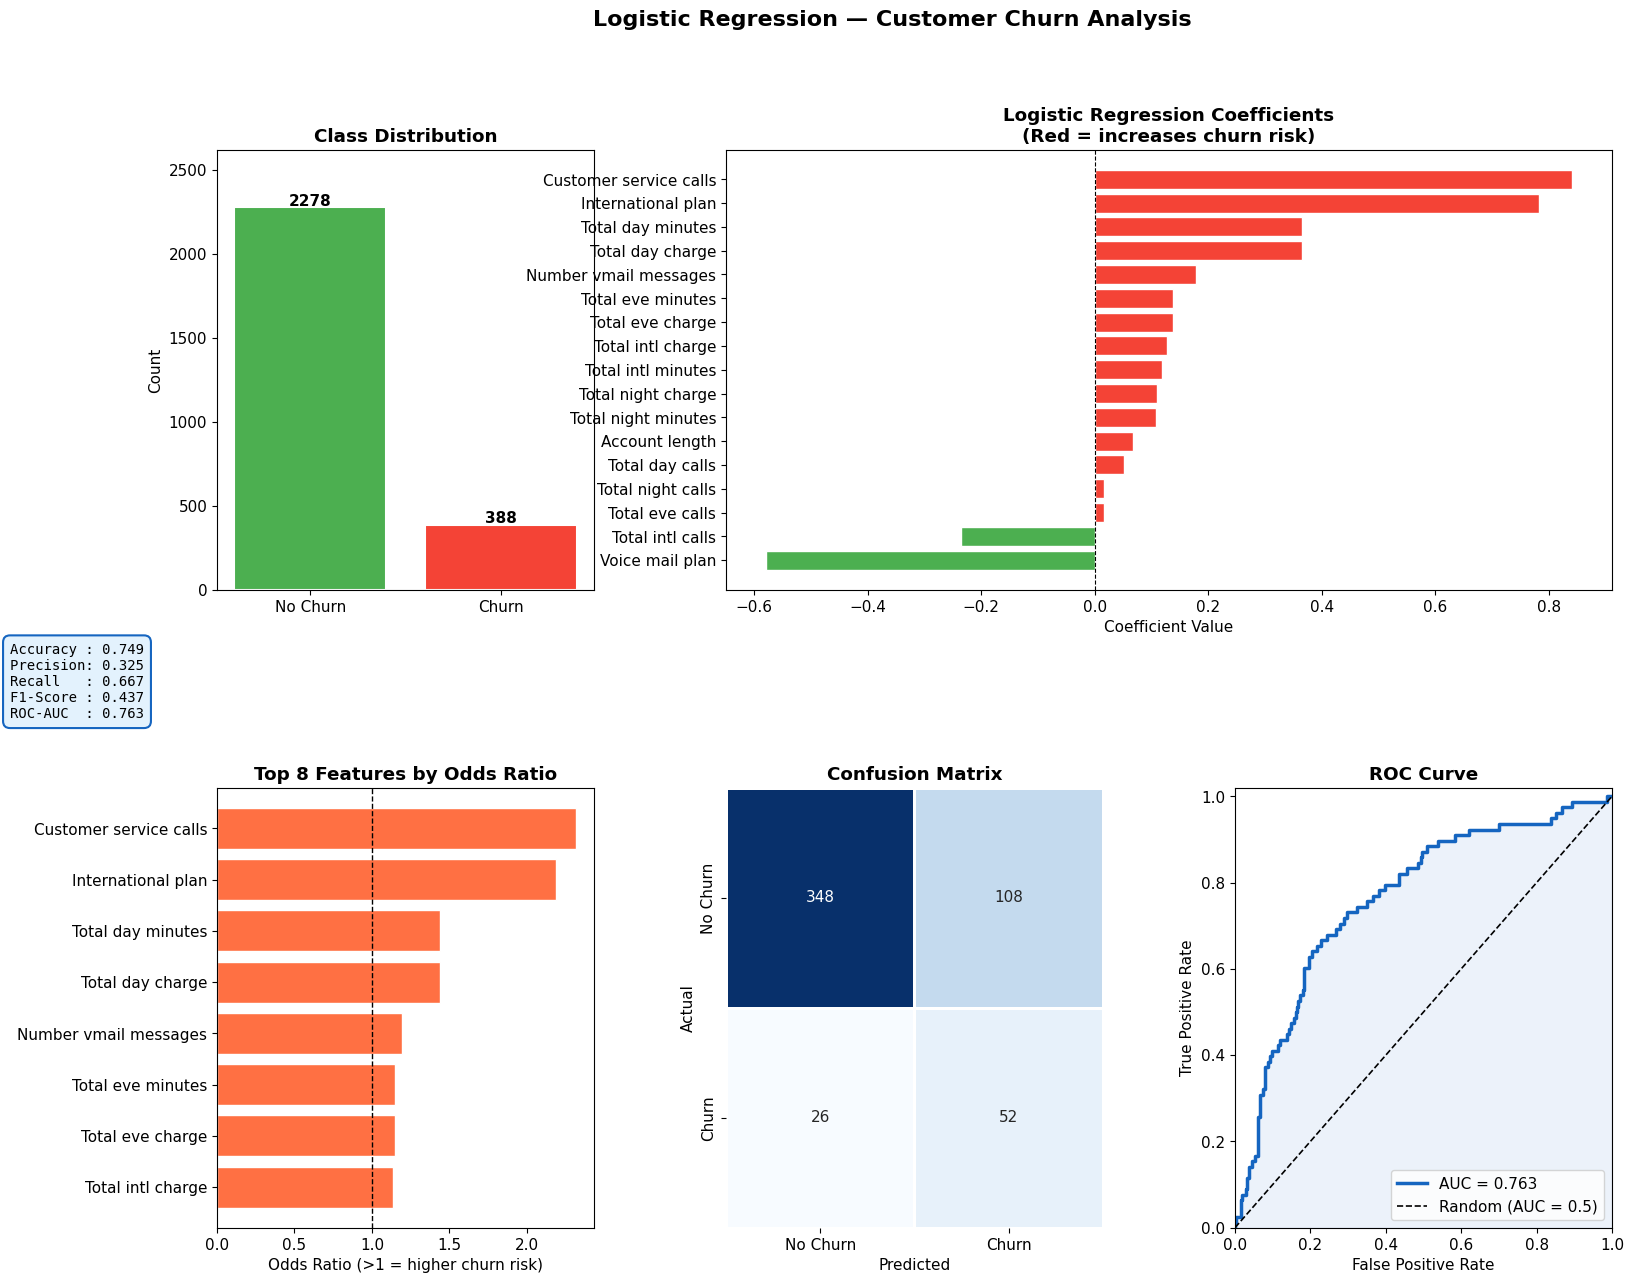

In [8]:
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Logistic Regression — Customer Churn Analysis", fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1 : Churn distribution ──────────────
ax1 = fig.add_subplot(gs[0, 0])
churn_counts = y.value_counts()
bars = ax1.bar(["No Churn", "Churn"], churn_counts.values,
               color=["#4CAF50", "#F44336"], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, churn_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha="center", fontweight="bold")
ax1.set_title("Class Distribution", fontweight="bold")
ax1.set_ylabel("Count")
ax1.set_ylim(0, max(churn_counts.values) * 1.15)

# ── Panel 2 : Coefficient bar chart ───────────
ax2 = fig.add_subplot(gs[0, 1:])
colors_coef = ["#F44336" if c > 0 else "#4CAF50" for c in coef_df["Coefficient"]]
ax2.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors_coef, edgecolor="white")
ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Logistic Regression Coefficients\n(Red = increases churn risk)", fontweight="bold")
ax2.set_xlabel("Coefficient Value")
ax2.invert_yaxis()

# ── Panel 3 : Odds ratio plot ──────────────────
ax3 = fig.add_subplot(gs[1, 0])
top_n = coef_df.nlargest(8, "Odds Ratio")
ax3.barh(top_n["Feature"], top_n["Odds Ratio"], color="#FF7043", edgecolor="white")
ax3.axvline(1, color="black", linewidth=1, linestyle="--")
ax3.set_title("Top 8 Features by Odds Ratio", fontweight="bold")
ax3.set_xlabel("Odds Ratio (>1 = higher churn risk)")
ax3.invert_yaxis()

# ── Panel 4 : Confusion matrix ────────────────
ax4 = fig.add_subplot(gs[1, 1])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            ax=ax4, cbar=False, linewidths=1)
ax4.set_title("Confusion Matrix", fontweight="bold")
ax4.set_ylabel("Actual")
ax4.set_xlabel("Predicted")

# ── Panel 5 : ROC curve ───────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(fpr, tpr, color="#1565C0", lw=2.5, label=f"AUC = {roc_auc:.3f}")
ax5.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random (AUC = 0.5)")
ax5.fill_between(fpr, tpr, alpha=0.08, color="#1565C0")
ax5.set_title("ROC Curve", fontweight="bold")
ax5.set_xlabel("False Positive Rate")
ax5.set_ylabel("True Positive Rate")
ax5.legend(loc="lower right")
ax5.set_xlim([0, 1])
ax5.set_ylim([0, 1.02])

# ── Metrics text box ──────────────────────────
metrics_text = (
    f"Accuracy : {acc:.3f}\n"
    f"Precision: {prec:.3f}\n"
    f"Recall   : {rec:.3f}\n"
    f"F1-Score : {f1:.3f}\n"
    f"ROC-AUC  : {roc_auc:.3f}"
)
fig.text(0.01, 0.50, metrics_text,
         fontsize=10, fontfamily="monospace",
         verticalalignment="center",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#E3F2FD", edgecolor="#1565C0", linewidth=1.5))
